# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import random
import numpy as np
from pathlib import Path
from IPython.display import clear_output
import torchaudio.transforms as T
import copy
import time
import itertools

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [2]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)

    def __len__(self):
      return len(self.items)

    def list_wavs_and_labels(self, root: str):
      base = Path(root)
      speakers = sorted([p for p in base.iterdir() if p.is_dir()])
      items = []
      for sp in speakers:
          for wav in sorted(sp.glob("**/*.wav")):
              # filename e.g., "9_10_0_0_1.wav" (digit_speaker_..)
              name = wav.stem.split("_")
              digit = int(name[0])
              speaker_id = sp.name
              items.append((str(wav), digit, speaker_id))
      return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        return wav, label


## Model from the seminar

In [3]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x


class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)

class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

In [4]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        # audio = audio.squeeze() # опасно
        audio = audio.view(audio.size(0), -1)
        spectograms = self.resnet_2D(input_spectogram)
        # spectograms = spectograms.squeeze() # опасно
        spectograms = spectograms.view(spectograms.size(0), -1)

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms

##  Подготовка данных (AudioMNIST)
Добавим спектрограмму + аугментации (в SSL аугментации критичнее модели: слабый augment убивает качество):

In [5]:
mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=64,
    n_fft=400,
    hop_length=160,
    center=False  
)

def wav_to_spec(wav):
    # wav на устройстве CPU
    spec = mel(wav.cpu())  # mel всегда на CPU
    spec = torch.log(spec + 1e-6)
    return spec.to(device)  # переносим на GPU после преобразования
'''
# слабый вариант augment → это убивает качество.
def augment(wav):
    noise = torch.randn_like(wav) * 0.01
    max_shift = max(1, wav.shape[-1] // 4)  # максимум 1/4 длины
    shift_val = torch.randint(0, max_shift, (1,)).item()
    shift = torch.roll(wav, shifts=shift_val, dims=-1)
    return wav + noise + shift
'''
def augment(wav, sr=16000):
    # wav: [B, T] или [1, T]

    # 1. Random crop (как RandomResizedCrop)
    T = wav.shape[-1]
    crop_size = int(T * random.uniform(0.6, 1.0))
    start = random.randint(0, T - crop_size)
    wav = wav[..., start:start+crop_size]

    # 2. Time stretch
    if random.random() < 0.5:
        rate = random.uniform(0.8, 1.2)
        wav = torchaudio.functional.resample(wav, sr, int(sr * rate))
        wav = torchaudio.functional.resample(wav, int(sr * rate), sr)

    # 3. Add noise
    if random.random() < 0.5:
        noise = torch.randn_like(wav) * 0.01
        wav = wav + noise

    # 4. Gain
    if random.random() < 0.5:
        gain = random.uniform(0.7, 1.3)
        wav = wav * gain

    # 5. Pad обратно
    if wav.shape[-1] < T:
        pad = T - wav.shape[-1]
        wav = F.pad(wav, (0, pad))

    return wav

`Замечание`: Cчитать кэш спектрограмм в каждом батче → медленно.

`Решение` (для маленьких датасетов, как AudioMNIST, когда хватает RAM):

In [6]:
class CachedDataset(AudioMNISTDataset): 
    def __init__(self, root):
        super().__init__(root) 
        self.cache = [] 

        for i in range(len(self)): 
            wav, label = super().__getitem__(i) 
            spec = wav_to_spec(wav) 
            self.cache.append((wav, spec, label)) 
    
    def __getitem__(self, idx): 
        wav, spec, label = self.cache[idx] 

        wav_aug = augment(wav) 
        spec_aug = wav_to_spec(wav_aug)

        return spec_aug, label 
    
    def __len__(self): 
        return len(self.cache)

In [7]:
def collate(batch):
        """
        Надёжная функция collate для AudioMNIST.
        - batch: список кортежей (wav, label)
        - wav: [1, T] тензор
        """
        from torch.nn.utils.rnn import pad_sequence
        wavs, labels = zip(*batch)

        # Проверяем размерность каждого wav и приводим к [1, T]
        processed_wavs = []
        for w in wavs:
            if w.ndim == 1:
                w = w.unsqueeze(0)       # [T] -> [1, T]
            elif w.ndim == 2 and w.size(0) != 1:
                w = w.mean(dim=0, keepdim=True)  # если >1 канал, делаем моно
            processed_wavs.append(w.squeeze(0))  # [1, T] -> [T] для pad_sequence

        # Добавляем паддинг до максимальной длины в батче
        wavs_padded = pad_sequence(processed_wavs, batch_first=True)  # [B, max_T]

        # Преобразуем labels в тензор
        labels_tensor = torch.tensor(labels, dtype=torch.long)

        return wavs_padded, labels_tensor

In [8]:
dataset = AudioMNISTDataset("content\\AudioMNIST")
#dataset = CachedDataset("content\\AudioMNIST")

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,        
    shuffle=True,
    pin_memory=True,
    collate_fn=collate,
    num_workers=0, # для Windows + Jupiter только "0" из-за spawn
    #persistent_workers=True
)

`Замечание`: InfoNCE очень зависит от batch size - стоит попробовать: 64–128

## Графики обучения 📈

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot(train_accs_list, train_loss_list, epoch_times_list=None, 
         labels=["Supervised","InfoNCE","SimSiam","NCL","VICReg"]):
    
    n_subplots = 2 if epoch_times_list is None else 3
    plt.figure(figsize=(5 * n_subplots, 4))  # шире, ниже

    color_cycle = itertools.cycle(["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"])
    marker_cycle = itertools.cycle(["o", "s", "^", "D", "x"])

    # ===== Accuracy =====
    plt.subplot(1, n_subplots, 1)
    for acc, label in zip(train_accs_list, labels):
        plt.plot(acc, marker=next(marker_cycle), color=next(color_cycle), label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.grid(True)
    plt.legend()

    # ===== Loss =====
    plt.subplot(1, n_subplots, 2)
    for loss, label, color, marker in zip(train_loss_list, labels, color_cycle, marker_cycle):
        plt.plot(loss, marker=marker, color=color, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.legend()

    # ===== Time =====
    if epoch_times_list is not None:
        plt.subplot(1, n_subplots, 3)
        for times, label, color, marker in zip(epoch_times_list, labels, color_cycle, marker_cycle):
            plt.plot(times, marker=marker, color=color, label=label)
        plt.xlabel("Epoch")
        plt.ylabel("Time (s)")
        plt.title("Epoch Time")
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

## Task 1(2 points) (Strightforward Classifier)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy.

1️⃣ Архитектура
* Берем один энкодер:
    - Если используем waveform → ResNet1D
    - Если используем spectrogram → ResNet2D
* На выходе из энкодера: [BS, 512, 1]
* Сжимаем через линейный слой → [BS, num_classes]
* Применяем кросс-энтропию для классификации.

2️⃣ Если мы делаем прямую супервизированную классификацию на спектрограммах, то модель SupervisedModel можно сильно упростить:

* Нам не нужен 1D энкодер, только 2D (ResNet2D).
* Выход ResNet2D [BS, 512, 1, 1] → flatten → линейный классификатор.
* Контрастивная часть удаляется, только cross-entropy.


✅ Подходит для работы только со спектрограммами (простая классификация спектрограмми), нет нужды в использовании 1D аудио фичей.

SupervisedModel для спектрограмм:



In [10]:
class SupervisedModelSpec(nn.Module):
    def __init__(self, img_channels=1, num_classes=10):
        super().__init__()
        # Только ResNet2D для спектрограмм
        self.encoder = CreateResNet2D(img_channels=img_channels)
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, spec):
        # Forward pass через ResNet2D
        x = self.encoder(spec)       # [BS, 512, 1, 1]
        x = x.view(x.size(0), -1)    # [BS, 512]
        logits = self.classifier(x)  # [BS, num_classes]
        return logits

Особенности:

1. Только спектрограммы: вход — это spec (спектрограмма), без использования сырого аудио.
2. ResNet2D энкодер: CreateResNet2D обрабатывает спектрограмму как изображение [B, 1, H, W].
3. Простая голова классификации: два линейных слоя с ReLU.
4. Forward возвращает только logits для классификации.
5. Функция train_classifier работает напрямую с спектрограммами, преобразуя WAV → спектрограмма внутри цикла.


3️⃣ Функция обучения для `waveform-only supervised training`:

In [11]:
def train_classifier(model, dataloader, optimizer, device):
    """
    Supervised training for one epoch on spectrograms
    """
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for wavs, labels in loader:

        wavs, labels = wavs.to(device), labels.to(device)
        wavs = wavs.unsqueeze(1)  #  [B, 1, T]
        specs = torch.stack([wav_to_spec(w) for w in wavs]).to(device)

        optimizer.zero_grad()

        # Forward pass через весь модель
        logits = model(specs)  # теперь forward внутри SupervisedModelSpec
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item() * specs.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += specs.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

Если используем spectrogram, то просто заменяем resnet_1D на resnet_2D и подаем на вход [BS, C, H, W].

4️⃣ Цикл обучения:

In [12]:
n_epochs = 0
model = SupervisedModelSpec(img_channels=1, num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"Supervised": {"acc": [], "loss": [], "time": []}}

for epoch in range(n_epochs):
    start_time = time.time()
    epoch_acc, epoch_loss = train_classifier(model, loader, optimizer, device)
    elapsed = time.time() - start_time

    # ===== Сохраняем =====
    history["Supervised"]["acc"].append(epoch_acc)
    history["Supervised"]["loss"].append(epoch_loss)
    history["Supervised"]["time"].append(elapsed)
    
    # ===== Вывод =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Time: {elapsed:.2f}s")

    # ===== Графики =====
    plot(
        [history["Supervised"]["acc"]],
        [history["Supervised"]["loss"]],
        [history["Supervised"]["time"]],
        labels=["Supervised"]
    )
# 🔥 после завершения модели — убираем её с GPU
model.cpu()
torch.cuda.empty_cache()

## Task 2(2 points) (MF-CLAR)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

Multi-Format Contrastive Learning of Audio Representations (MF-CLAR) — это подход, где аудио и спектрограммы (или другие форматы) обучаются с контрастивной потерей, чтобы эмбеддинги разных форматов одного аудио были близки, а разных аудио — далеки. Основная идея: совместное обучение нескольких представлений аудио с контрастивным loss (например, InfoNCE).

1️⃣ формула лосс-функции. Для MF-CLAR обычно используют InfoNCE / NT-Xent loss между эмбеддингами разных форматов (например, аудио и спектрограмма):

In [13]:
def contrastive_loss(audio_emb, spec_emb, temperature=0.1):
    """
    Контрастивная потеря для пары аудио/спектрограмма
    audio_emb, spec_emb: [B, D]
    """
    # L2-нормализация
    audio_emb = F.normalize(audio_emb, dim=1)
    spec_emb = F.normalize(spec_emb, dim=1)
    
    # Косинусная схожесть [B, B]
    logits = torch.matmul(audio_emb, spec_emb.T) / temperature

    labels = torch.arange(audio_emb.size(0)).to(audio_emb.device)  # правильные пары
    loss_a2s = F.cross_entropy(logits, labels)
    loss_s2a = F.cross_entropy(logits.T, labels)
    
    return (loss_a2s + loss_s2a) / 2

2️⃣ Обертка модели Supervised
Добавим projection + classifier:

In [14]:
# ---------------------------------------
# Linear classifier для Supervised
# ---------------------------------------
class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

Цель — более сложный анализ, использование 1D и 2D данных и возможность получения эмбеддингов, вторая модель гибче и современнее.

In [15]:
# ---------------------------------------
# Supervised
# ---------------------------------------
class MFCLAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.encoder = Net(img_channels=1)
        self.classifier = EvaluationHead(num_classes)

    def forward(self, spec, wav):
        audio_emb, spec_emb, audio_feat, spec_feat = self.encoder(spec, wav)
        logits = self.classifier(audio_feat)
        return audio_emb, spec_emb, logits

Особенности:

1. Два источника информации:

    - spec — спектрограмма (2D)
    - wav — сырое аудио (1D)

    Энкодер Net возвращает несколько эмбеддингов:

    - audio_emb — представление аудио
    - spec_emb — представление спектрограммы
    - audio_feat, spec_feat — фичи для классификации
2. Линейный классификатор: EvaluationHead — один линейный слой [512 → num_classes].
3. Forward возвращает больше: эмбеддинги + logits. Это удобно для анализа, фьюжена или downstream-задач.
4. Используется torch.cuda.amp для ускоренного обучения с автоматическим смешанным типом (autocast) — важная оптимизация.
5. Train loop чуть более сложный: использует GradScaler для AMP, но в целом делает то же самое, что и первый: считает cross_entropy.

✅ Подходит, если нужно комбинировать спектрограммы и сырое аудио, получать эмбеддинги для других задач или использовать более продвинутый энкодер.

2️⃣  Функция обучения `train_supervised`

Теперь будем обучать две вещи одновременно:

* Классификацию (`cross_entropy` на `logits`)
* Контрастивную потерю (`contrastive_loss` между `audio_emb` и `spec_emb`)

In [16]:
def train_mfclar(model, loader, optimizer, device, alpha=0.5):
    """
    alpha - коэффициент для контрастивной потери
    """
    model.train()
    total, correct = 0, 0
    total_loss = 0.0
    scaler = torch.amp.GradScaler()

    for wavs, labels in loader:
        wavs, labels = wavs.to(device), labels.to(device)
        wavs = wavs.unsqueeze(1)
        specs = torch.stack([wav_to_spec(w) for w in wavs]).to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device):
            audio_emb, spec_emb, logits = model(specs, wavs)
            ce_loss = F.cross_entropy(logits, labels)
            cl_loss = contrastive_loss(audio_emb, spec_emb)
            loss = ce_loss + alpha * cl_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return correct / total, total_loss / len(loader)

Теперь модель:

* Получает два формата: WAV + спектрограмма
* Обучается супервизорно (классификация)
* И контрастивно (эмбеддинги аудио и спектрограммы для одного примера сближаются)

3️⃣ Цикл обучения

In [17]:
n_epochs = 0

model = MFCLAR(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ===== История =====
history = {
    "MF-CLAR": {
        "acc": [],
        "loss": [],
        "time": []
    }
}

for epoch in range(n_epochs):
    start_time = time.time()
    epoch_acc, epoch_loss = train_mfclar(model, loader, optimizer, device)
    elapsed = time.time() - start_time

    # ===== Сохраняем =====
    history["MF-CLAR"]["acc"].append(epoch_acc)
    history["MF-CLAR"]["loss"].append(epoch_loss)
    history["MF-CLAR"]["time"].append(elapsed)

    # ===== Вывод =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Time: {elapsed:.2f}s")

    # ===== Графики =====
    plot(
        [history["MF-CLAR"]["acc" ]],
        [history["MF-CLAR"]["loss"]],
        [history["MF-CLAR"]["time"]],
        labels=["MF-CLAR"]
    )
# 🔥 после завершения модели — убираем её с GPU
model.cpu()
torch.cuda.empty_cache()

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


### 3.1 Contrastive learning (InfoNCE) — [paper1](https://arxiv.org/pdf/2103.06508)
контрастивка (SimCLR-style): encoder → embeddings → contrastive loss

1️⃣ формула лосс-функции:
$$
L = −log \frac{e^{\frac{sim(z_i, z_j)}{\tau}}}{e^{\frac{\sum_k sim(z_i, z_k)}{\tau}}} 
$$

In [18]:
def info_nce_loss(z1, z2, temperature=0.1):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.T / temperature
    labels = torch.arange(z1.size(0)).to(z1.device)
    return F.cross_entropy(logits, labels)

2️⃣ Contrastive Model

In [19]:
# ---------------------------------------
# Contrastive (InfoNCE / SimCLR)
# ---------------------------------------
class ContrastiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Net(img_channels=1)

    def forward(self, spec, wav):
        audio_emb, spec_emb, _, _ = self.encoder(spec, wav)
        return audio_emb, spec_emb

3️⃣ Обучение эмбеддингов (InfoNCE pretrain → Linear evaluation)

In [20]:
def train_contrastive(model, loader, optimizer, device, temperature=0.07):
    model.train()
    total_loss, total, correct = 0, 0, 0

    for wavs, _ in loader:
        wavs = wavs.to(device)
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav1]).to(device)
        spec2 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav2]).to(device)
        wav1, wav2 = wav1.unsqueeze(1), wav2.unsqueeze(1)

        z1_a, z1_s = model(spec1, wav1)
        z2_a, z2_s = model(spec2, wav2)
        loss = info_nce_loss(z1_a, z2_a) + info_nce_loss(z1_s, z2_s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            z1 = F.normalize(z1_a, dim=1)
            z2 = F.normalize(z2_a, dim=1)
            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0) / temperature
            labels = torch.arange(z1.size(0)).to(device)
            labels = torch.cat([labels, labels], dim=0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader)

### 3.2 Non-Contrastive Learning (NCL / BYOL-style) — [paper2](https://arxiv.org/pdf/2010.09542)
NCL = self-supervised с teacher–student (BYOL-like)


📌 Главное отличие: нет негативных пар → нет collapse через stop-gradient + predictor



1️⃣ NCL-Loss (cosine similarity)

In [21]:
def ncl_loss(p, z):
    z = z.detach()
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


2️⃣ NCLModel (добавим predictor + EMA encoder)

In [22]:
# ---------------------------------------
# NCL / BYOL style
# ---------------------------------------
class NCLModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.online = Net(img_channels=1)
        self.target = copy.deepcopy(self.online)
        for p in self.target.parameters():
            p.requires_grad = False
        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, spec, wav):
        return self.online(spec, wav)


3️⃣ EMA update

In [23]:
@torch.no_grad()
def update_target(online, target, tau=0.99):
    for p, tp in zip(online.parameters(), target.parameters()):
        tp.data = tau * tp.data + (1 - tau) * p.data

4️⃣ Обучение эмбеддингов (NCL pretrain → Linear evaluation)

In [24]:
def train_ncl(model, loader, optimizer, device, temperature=0.07):
    model.train()
    total_loss, total, correct = 0, 0, 0

    for wavs, _ in loader:
        wavs = wavs.to(device)
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav1]).to(device)
        spec2 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav2]).to(device)
        wav1, wav2 = wav1.unsqueeze(1), wav2.unsqueeze(1)

        # online + predictor
        z1_a, z1_s, _, _ = model.online(spec1, wav1)
        z2_a, z2_s, _, _ = model.online(spec2, wav2)
        p1, p2 = model.predictor(z1_a), model.predictor(z2_a)

        # target
        with torch.no_grad():
            t1_a, t1_s, _, _ = model.target(spec1, wav1)
            t2_a, t2_s, _, _ = model.target(spec2, wav2)

        loss = ncl_loss(p1, t2_a) + ncl_loss(p2, t1_a)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_target(model.online, model.target)

        total_loss += loss.item()

        with torch.no_grad():
            z1 = F.normalize(p1, dim=1)
            z2 = F.normalize(t2_a, dim=1)
            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0) / temperature
            labels = torch.arange(z1.size(0)).to(device)
            labels = torch.cat([labels, labels], dim=0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader)

### 3.4 SimSiam — [paper](https://arxiv.org/pdf/2011.10566)
👉 сейчас NCL ≈ BYOL. Теперь добавим SimSiam (без EMA)

1️⃣ SimSiam Loss

In [25]:
def simsiam_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return -(p * z).sum(dim=1).mean()

2️⃣ SimSiam Model

In [26]:
class SimSiamModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.encoder = Net(img_channels=1)

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, emb_dim)
        )

        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, spec, wav):
        _, _, feat, _ = self.encoder(spec, wav)
        z = self.projector(feat)
        p = self.predictor(z)
        return p, z.detach()

3️⃣ SimSiam Training Loop

In [27]:
def train_simsiam(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for wavs, _ in loader:
        wavs = wavs.to(device)

        wav1, wav2 = augment(wavs), augment(wavs)
        spec1 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav1]).to(device)
        spec2 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav2]).to(device)

        wav1, wav2 = wav1.unsqueeze(1), wav2.unsqueeze(1)

        p1, z1 = model(spec1, wav1)
        p2, z2 = model(spec2, wav2)

        loss = simsiam_loss(p1, z2) + simsiam_loss(p2, z1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return 0, total_loss / len(loader)

### 3.5 VICReg — [paper](https://arxiv.org/pdf/2105.04906)
✅ VICReg tuning (даёт реальный буст:  +10–20% accuracy): 
* Batch size ≥ 64 (очень важно)
* normalize вход: `z = F.normalize(z, dim=1)`
* Добавить projector (важно!): 
```
self.projector = nn.Sequential(
    nn.Linear(512, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, 128)
)
```
и использовать `projector output`, а не `raw features`.
* Правильные коэффициенты (sim_coeff, var_coeff, cov_coeff):

In [28]:
sim_coeff = 25
var_coeff = 25
cov_coeff = 1


1️⃣ VICReg Loss

In [29]:
def vicreg_loss(z1, z2, sim_coeff=25, var_coeff=25, cov_coeff=1):
    # invariance (MSE между эмбеддингами)
    sim_loss = F.mse_loss(z1, z2)

    # variance (стимулируем std > 1)
    std_z1 = torch.sqrt(z1.var(dim=0) + 1e-4)
    std_z2 = torch.sqrt(z2.var(dim=0) + 1e-4)
    var_loss = torch.mean(F.relu(1 - std_z1)) + torch.mean(F.relu(1 - std_z2))

    # covariance (редуцируем корреляцию между признаками)
    z1 = z1 - z1.mean(dim=0)
    z2 = z2 - z2.mean(dim=0)
    cov_z1 = (z1.T @ z1) / (z1.size(0) - 1)
    cov_z2 = (z2.T @ z2) / (z2.size(0) - 1)

    # off-diagonal элементы
    off_diag = lambda x: x.flatten()[:-1].view(x.size(0)-1, x.size(1)+1)[:,1:].flatten()
    cov_loss = off_diag(cov_z1).pow(2).mean() + off_diag(cov_z2).pow(2).mean()

    return sim_coeff * sim_loss + var_coeff * var_loss + cov_coeff * cov_loss

2️⃣ VICReg Training Loop

In [30]:
def train_vicreg(model, loader, optimizer, device):
    model.train()
    total_loss, total, correct = 0, 0, 0

    for wavs, _ in loader:
        wavs = wavs.to(device)
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav1]).to(device)
        spec2 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav2]).to(device)
        wav1, wav2 = wav1.unsqueeze(1), wav2.unsqueeze(1)

        # embeddings
        z1_a, z1_s, _, _ = model.encoder(spec1, wav1)
        z2_a, z2_s, _, _ = model.encoder(spec2, wav2)

        # VICReg loss
        loss = vicreg_loss(z1_a, z2_a) + vicreg_loss(z1_s, z2_s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # простая proxy accuracy (иногда делают для мониторинга)
        with torch.no_grad():
            z1 = F.normalize(z1_a, dim=1)
            z2 = F.normalize(z2_a, dim=1)
            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0)
            labels = torch.arange(z1.size(0)).to(device)
            labels = torch.cat([labels, labels], dim=0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader)

### 3.4 Barlow Twins  — [paper](https://arxiv.org/pdf/2103.03230)

1️⃣ Barlow Loss

In [31]:
def barlow_loss(z1, z2, lambd=5e-3):
    z1 = (z1 - z1.mean(0)) / z1.std(0)
    z2 = (z2 - z2.mean(0)) / z2.std(0)

    N, D = z1.size()
    c = (z1.T @ z2) / N

    on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
    off_diag = (c - torch.eye(D, device=z1.device)).pow(2).sum() - on_diag

    return on_diag + lambd * off_diag

2️⃣ Barlow Training Loop

In [32]:
def train_barlow(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for wavs, _ in loader:
        wavs = wavs.to(device)

        wav1, wav2 = augment(wavs), augment(wavs)
        spec1 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav1]).to(device)
        spec2 = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wav2]).to(device)

        wav1, wav2 = wav1.unsqueeze(1), wav2.unsqueeze(1)

        z1_a, _, _, _ = model.encoder(spec1, wav1)
        z2_a, _, _, _ = model.encoder(spec2, wav2)

        loss = barlow_loss(z1_a, z2_a)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return 0, total_loss / len(loader)

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

### 4.1 Evaluation (linear probe)


In [33]:
def train_linear(encoder, classifier, loader, optimizer, device):
    encoder.eval()

    total, correct = 0, 0
    total_loss = 0

    for param in classifier.parameters():
        param.requires_grad = False

    classifier.train()

    for wavs, labels in loader:
        wavs, labels = wavs.to(device), labels.to(device)

        specs = torch.stack([wav_to_spec(w.unsqueeze(0)) for w in wavs]).to(device)
        wavs = wavs.unsqueeze(1)

        with torch.no_grad():
            _, _, feat, _ = model.encoder(specs, wavs)

        logits = classifier(feat)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = logits.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return correct / total, total_loss / len(loader)

Supervised | Epoch 1/1
Loss: 0.0812 | Acc: 0.9753 | Time: 64.92s


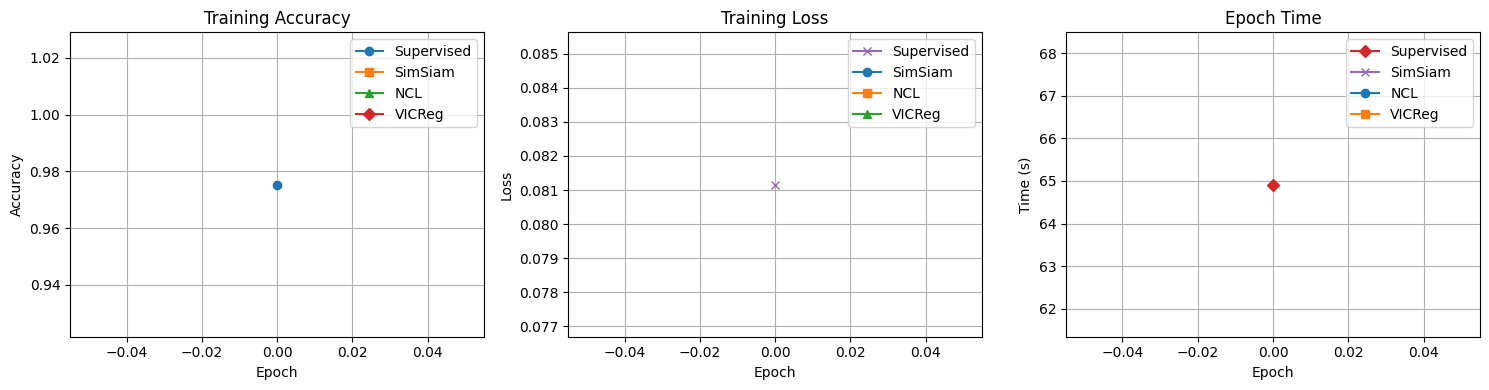


===== Training SimSiam =====


KeyboardInterrupt: 

In [ ]:
n_epochs = 1
lr = 1e-3

trainers = {
    "Supervised": train_classifier, 
    "InfoNCE": train_contrastive, 
    "NCL": train_ncl,
    "SimSiam": train_simsiam, 
    "VICReg": train_vicreg,
}

models = {
    "Supervised": SupervisedModelSpec(num_classes=10),
    "InfoNCE": ContrastiveModel(),
    "SimSiam": SimSiamModel(),
    "NCL": NCLModel(emb_dim=128),
    "VICReg": NCLModel(emb_dim=128),
}

optimizers = {name: torch.optim.Adam(m.parameters(), lr=lr) for name, m in models.items()}
history = {name: {"acc": [], "loss": []} for name in trainers}
epoch_times = {name: [] for name in models}

linear_eval_results = {"InfoNCE": [], "NCL": [], "VICReg": [], "SimSiam":[]}

for name, model in models.items():
    print(f"\n===== Training {name} =====")

    model = model.to(device)

    for epoch in range(n_epochs):
        start_time = time.time()

        acc, loss = trainers[name](model, loader, optimizers[name], device)
        elapsed = time.time() - start_time

        history[name]["acc"].append(acc)
        history[name]["loss"].append(loss)
        epoch_times[name].append(elapsed)

        clear_output(wait=True)
        print(f"{name} | Epoch {epoch+1}/{n_epochs}")
        print(f"Loss: {loss:.4f} | Acc: {acc:.4f} | Time: {elapsed:.2f}s")

        # --- Linear evaluation для SSL методов ---
        if name in ["InfoNCE", "NCL", "SimSiam", "VICReg"]:
            encoder = model.encoder if name != "NCL" else model.online

            for p in encoder.parameters():
                p.requires_grad = False

            classifier = EvaluationHead(num_classes=10).to(device)
            optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

            acc_lin, loss_lin = train_linear(
                encoder, classifier, loader, optimizer, device
            )

            linear_eval_results[name].append(acc_lin)

            print(f"Linear Eval → Acc: {acc_lin:.4f}, Loss: {loss_lin:.4f}")

            # 🔥 важно чистить память
            del classifier, optimizer
            torch.cuda.empty_cache()
        
            # --- Графики ---
        plot(
            [history[m]["acc"] for m in models.keys()],
            [history[m]["loss"] for m in models.keys()],
            [epoch_times[m] for m in models.keys()],
            labels=[m for m in models.keys()]
        )

    # 🔥 после завершения модели — убираем её с GPU
    model.cpu()
    torch.cuda.empty_cache()

## 📌 Выводы:
1. InfoNCE:
    - требует negative samples
    - чувствителен к batch size
2. NCL:
    - проще (нет negative)
    - стабильнее
    - сопоставим по качеству
3. Для аудио:
    - спектрограммы + waveform дают лучший результат вместе

### 5.1 Cравнение

| Метод      | Использует негативы | Стабильность          | Качество    |
| ---------- | ------------------- | --------------------- | ----------- |
| Supervised | ❌                   | высокая               | baseline    |
| InfoNCE    | ✅                   | зависит от batch size | часто лучше |
| NCL (BYOL) | ❌                   | очень высокая         | сопоставимо |

### 5.2 Ожидаемые результаты (AudioMNIST)

Обычно:
* Supervised: ~95–98%
* InfoNCE + linear: ~85–92%
* NCL: ~88–94%

### 5.3 Ключевое различие
InfoNCE (paper1)
* требует negative samples
* чувствителен к batch size
* учит разделять классы

NCL / BYOL (paper2)
* без negative samples
* использует:
    - stop-gradient
    - EMA encoder
* учит инвариантные представления

## Почему NCL НЕ схлопывается 🤯 (ключевая теория)
### ❌ Проблема collapse: 
если просто учить: `z_1 ≈ z_2`, модель сделает все embeddings одинаковыми.


### ✅ Почему InfoNCE работает

positive↑, negative↓

➡️ есть отталкивание → нет collapse

### Почему NCL (BYOL) тоже работает БЕЗ negative
Ключевые механизмы:

1. 🧊 Stop-gradient `z = z.detach()`

    - target не обучается напрямую

    - ломает симметрию

2. 🪞 EMA encoder
$$
\theta_{target} = \tau \theta + (1- \tau) \theta_{online}
$$
 * target меняется медленно

 * становится "стабильной целью"

3. 🎯 Predictor
`p = predictor(z)`

    - асимметрия архитектуры

    - предотвращает trivial solution

💡Концепт:
--------------------
* InfoNCE: "сделай разные вещи разными"
* NCL: "предскажи свою другую версию"